# Exploratory Data Analysis:

---

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
data = pd.read_csv("employee_attrition.csv")

In [3]:
print("No. of rows:", data.shape[0])
print("No. of columns:", data.shape[1])

No. of rows: 1518
No. of columns: 16


In [4]:
print(f"Missing Values (in %age):\n{((data.isna().sum() / len(data))*100).sort_values(ascending=False).round(3)}")

Missing Values (in %age):
WorkLifeBalance       4.018
MonthlyIncome         3.953
TrainingHours         3.953
EmployeeID            0.000
Age                   0.000
Gender                0.000
Department            0.000
JobLevel              0.000
YearsAtCompany        0.000
Overtime              0.000
DistanceFromHome      0.000
NumCompaniesWorked    0.000
PerformanceRating     0.000
SatisfactionScore     0.000
Attrition             0.000
BadgeNumber           0.000
dtype: float64


In [5]:
print("Duplicated Values:", data.duplicated().sum())

Duplicated Values: 0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          1518 non-null   int64  
 1   Age                 1518 non-null   int64  
 2   Gender              1518 non-null   object 
 3   Department          1518 non-null   object 
 4   JobLevel            1518 non-null   int64  
 5   YearsAtCompany      1518 non-null   int64  
 6   MonthlyIncome       1458 non-null   float64
 7   Overtime            1518 non-null   object 
 8   WorkLifeBalance     1457 non-null   object 
 9   DistanceFromHome    1518 non-null   int64  
 10  NumCompaniesWorked  1518 non-null   int64  
 11  TrainingHours       1458 non-null   float64
 12  PerformanceRating   1518 non-null   object 
 13  SatisfactionScore   1518 non-null   int64  
 14  Attrition           1518 non-null   object 
 15  BadgeNumber         1518 non-null   int64  
dtypes: flo

In [7]:
data.describe()

,EmployeeID,Age,JobLevel,YearsAtCompany,MonthlyIncome,DistanceFromHome,NumCompaniesWorked,TrainingHours,SatisfactionScore,BadgeNumber
count,1518.000000,1518.000000,1518.000000,1518.000000,1458.000000,1518.000000,1518.000000,1458.000000,1518.000000,1518.000000
mean,10752.031621,40.569170,2.330698,16.880105,62747.508916,22.353755,4.452569,42.353224,5.401845,543882.038208
std,433.352657,11.371252,1.178244,10.075397,28533.131396,12.869535,2.887712,21.538350,2.893959,264602.410663
min,10001.000000,21.000000,1.000000,0.000000,1676.000000,1.000000,0.000000,5.000000,1.000000,100503.000000
25%,10378.250000,31.000000,1.000000,8.000000,42982.000000,11.000000,2.000000,23.000000,3.000000,309827.750000
50%,10751.500000,41.000000,2.000000,17.000000,59626.000000,23.000000,4.000000,43.000000,5.000000,530524.000000
75%,11126.750000,50.000000,3.000000,25.000000,79877.000000,33.000000,7.000000,61.000000,8.000000,776739.750000
max,11500.000000,59.000000,5.000000,34.000000,360129.000000,88.000000,9.000000,79.000000,10.000000,999622.000000


In [8]:
data.sample(10)

,EmployeeID,Age,Gender,Department,JobLevel,YearsAtCompany,MonthlyIncome,Overtime,WorkLifeBalance,DistanceFromHome,NumCompaniesWorked,TrainingHours,PerformanceRating,SatisfactionScore,Attrition,BadgeNumber
313,10314,37,Female,IT,3,3,56499.0,No,Fair,31,2,22.0,Average,4,No,794275
753,10754,34,Male,Finance,5,29,136646.0,No,Fair,10,0,30.0,High,7,No,679984
1162,11163,46,Female,Finance,3,16,79938.0,No,Good,18,0,14.0,Average,2,No,397991
914,10915,59,Male,IT,3,12,85750.0,No,Fair,35,9,59.0,Average,2,No,344085
921,10922,47,Male,Sales,4,10,88246.0,No,Fair,32,0,40.0,Average,3,No,850708
1049,11050,30,Female,Marketing,3,25,77438.0,Yes,Fair,32,8,77.0,Average,4,No,877740
470,10471,43,Male,Sales,1,24,55243.0,No,Poor,1,0,37.0,Average,1,No,877331
288,10289,26,Male,Sales,3,2,51471.0,Yes,NaN,21,0,17.0,High,7,No,225185
1348,11349,45,Female,HR,2,10,50374.0,Yes,Good,18,8,79.0,High,10,No,489273
245,10246,55,Male,Sales,2,8,41105.0,No,Excellent,13,2,43.0,Average,7,No,879177


Attrition
No     1439
Yes      79
Name: count, dtype: int64


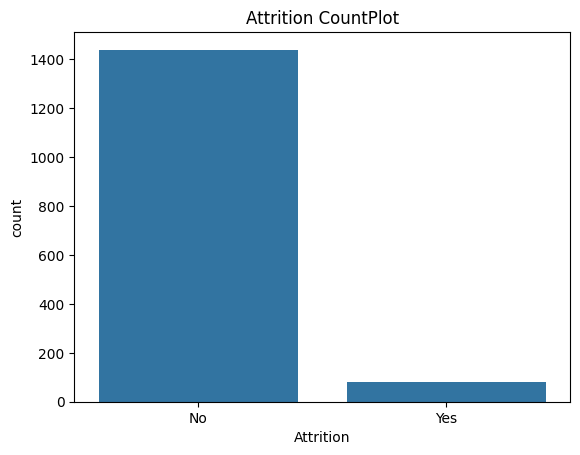

In [9]:
print(data['Attrition'].value_counts())

sns.countplot(data=data, x=data['Attrition'])
plt.title('Attrition CountPlot')
plt.show()

In [10]:
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['Gender', 'Department', 'Overtime', 'WorkLifeBalance', 'PerformanceRating', 'Attrition']


In [11]:
pd.crosstab(data['Gender'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
Gender,,
Female,94.68,5.32
Male,94.92,5.08


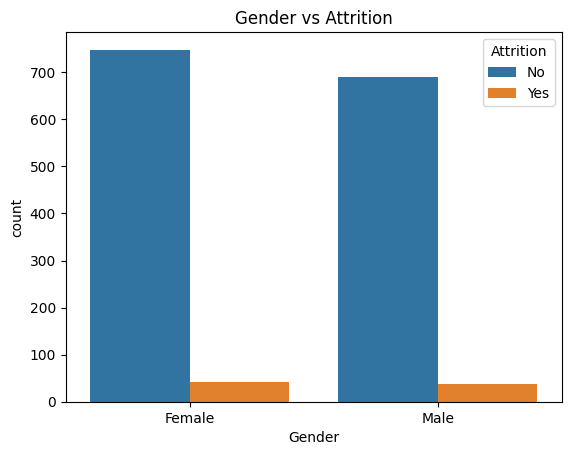

In [12]:
sns.countplot(data=data, x='Gender', hue='Attrition')
plt.title('Gender vs Attrition')

plt.show()

In [13]:
pd.crosstab(data['Department'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
Department,,
Finance,96.09,3.91
HR,96.36,3.64
IT,93.62,6.38
Marketing,97.37,2.63
Sales,93.23,6.77


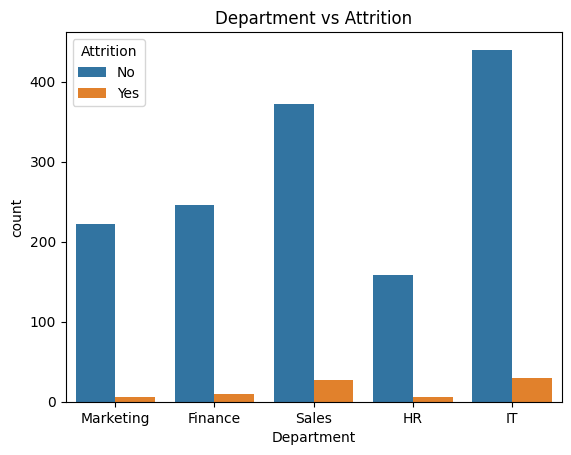

In [14]:
sns.countplot(data=data, x='Department', hue='Attrition')
plt.title('Department vs Attrition')

plt.show()

In [15]:
pd.crosstab(data['Overtime'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
Overtime,,
No,96.83,3.17
Yes,91.09,8.91


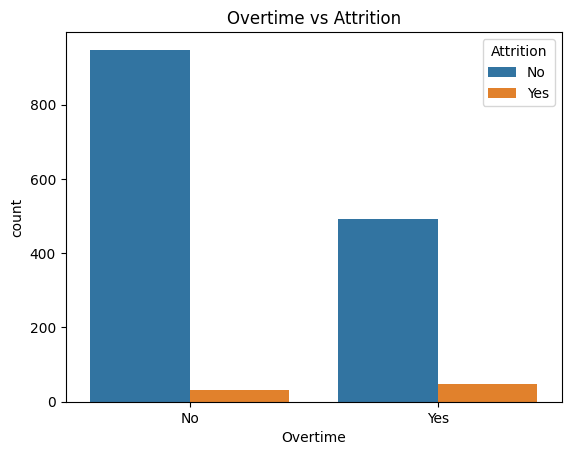

In [16]:
sns.countplot(data=data, x='Overtime', hue='Attrition')
plt.title('Overtime vs Attrition')

plt.show()

In [17]:
pd.crosstab(data['WorkLifeBalance'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
WorkLifeBalance,,
Excellent,94.26,5.74
Fair,96.25,3.75
Good,94.81,5.19
Poor,91.43,8.57


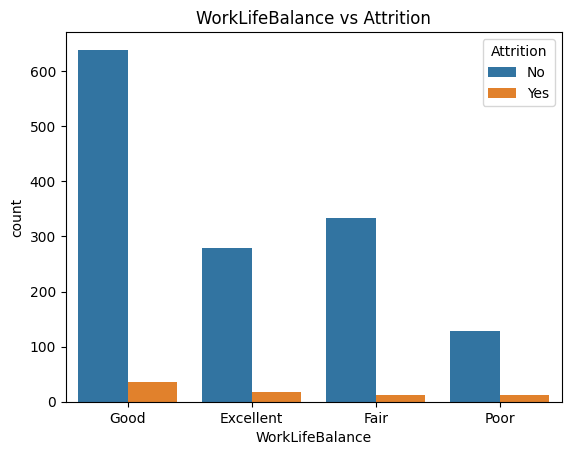

In [18]:
sns.countplot(data=data, x='WorkLifeBalance', hue='Attrition')
plt.title('WorkLifeBalance vs Attrition')

plt.show()

In [19]:
pd.crosstab(data['PerformanceRating'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
PerformanceRating,,
Average,95.34,4.66
High,94.81,5.19
Low,91.67,8.33


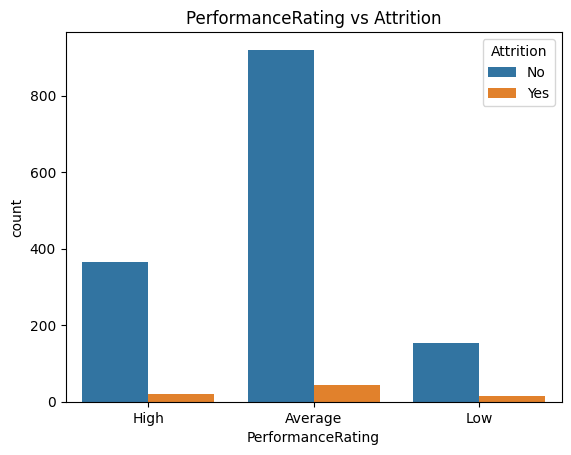

In [20]:
sns.countplot(data=data, x='PerformanceRating', hue='Attrition')
plt.title('PerformanceRating vs Attrition')

plt.show()

In [21]:
numerical_cols = data.select_dtypes(include=['int', 'float']).columns.tolist()
print(numerical_cols)

['EmployeeID', 'Age', 'JobLevel', 'YearsAtCompany', 'MonthlyIncome', 'DistanceFromHome', 'NumCompaniesWorked', 'TrainingHours', 'SatisfactionScore', 'BadgeNumber']


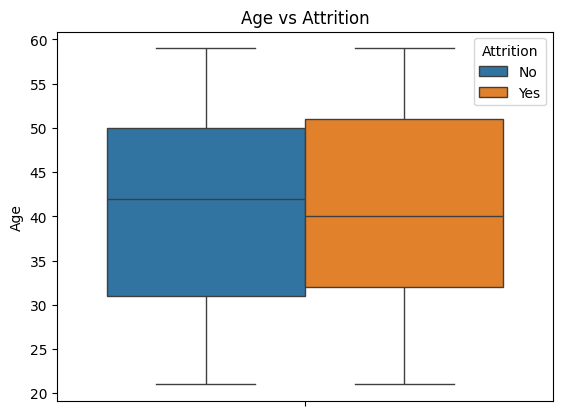

In [22]:
sns.boxplot(data=data, y='Age', hue='Attrition')
plt.title('Age vs Attrition')

plt.show()

In [23]:
pd.crosstab(data['JobLevel'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
JobLevel,,
1,92.44,7.56
2,95.63,4.37
3,94.17,5.83
4,98.23,1.77
5,98.36,1.64


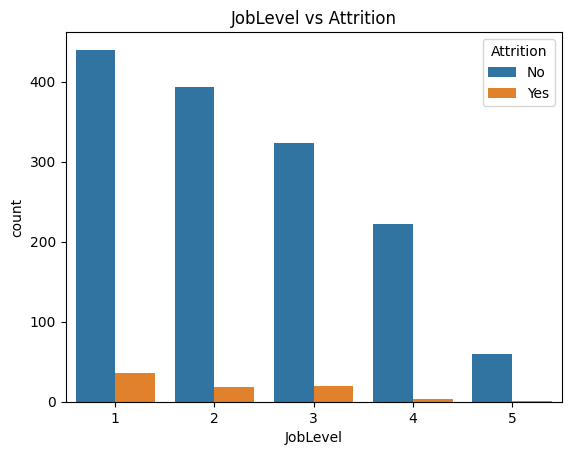

In [24]:
sns.countplot(data=data, x='JobLevel', hue='Attrition')
plt.title('JobLevel vs Attrition')

plt.show()

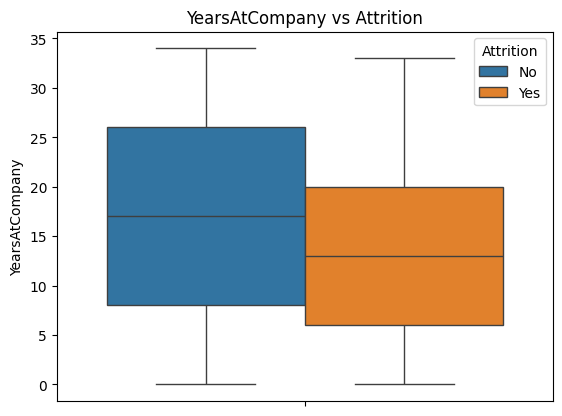

In [25]:
sns.boxplot(data=data, y='YearsAtCompany', hue='Attrition')
plt.title('YearsAtCompany vs Attrition')

plt.show()

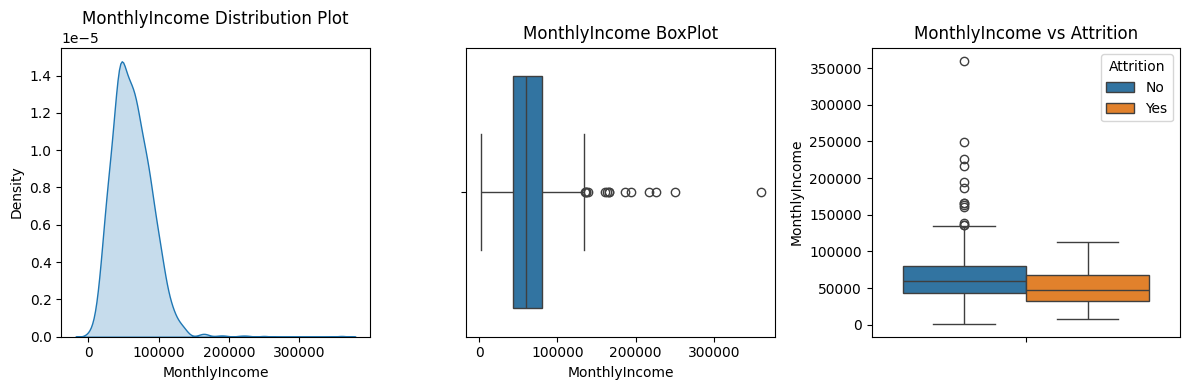

Skewness: 1.637


In [26]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

sns.kdeplot(data=data, x='MonthlyIncome', fill=True, ax=ax[0])
ax[0].set_title('MonthlyIncome Distribution Plot')

sns.boxplot(data=data, x='MonthlyIncome', ax=ax[1])
ax[1].set_title('MonthlyIncome BoxPlot')

sns.boxplot(data=data, y='MonthlyIncome', hue='Attrition', ax=ax[2])
ax[2].set_title('MonthlyIncome vs Attrition')

plt.tight_layout()
plt.show()

print("Skewness:", data['MonthlyIncome'].skew().round(3))

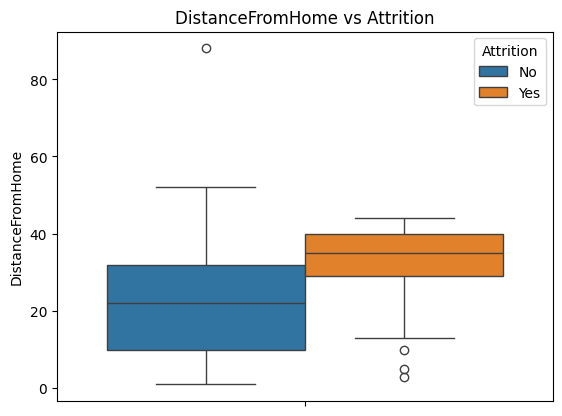

In [27]:
sns.boxplot(data=data, y='DistanceFromHome', hue='Attrition')
plt.title('DistanceFromHome vs Attrition')

plt.show()

In [28]:
pd.crosstab(data['NumCompaniesWorked'], data['Attrition'], normalize='index').round(4) * 100

Attrition,No,Yes
NumCompaniesWorked,,
0,92.67,7.33
1,95.15,4.85
2,96.75,3.25
3,95.54,4.46
4,93.84,6.16
5,94.94,5.06
6,95.45,4.55
7,97.44,2.56
8,90.91,9.09


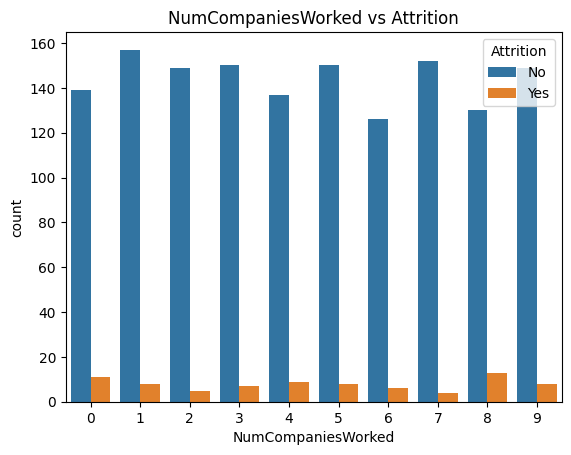

In [29]:
sns.countplot(data=data, x='NumCompaniesWorked', hue='Attrition')
plt.title('NumCompaniesWorked vs Attrition')

plt.show()

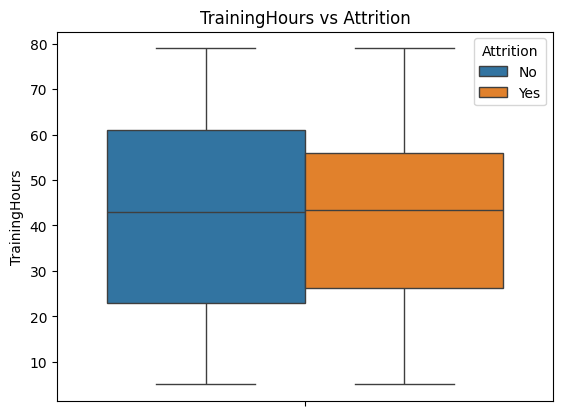

In [30]:
sns.boxplot(data=data, y='TrainingHours', hue='Attrition')
plt.title('TrainingHours vs Attrition')

plt.show()

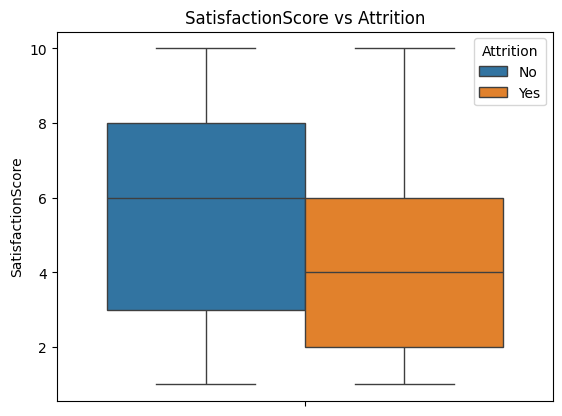

In [31]:
sns.boxplot(data=data, y='SatisfactionScore', hue='Attrition')
plt.title('SatisfactionScore vs Attrition')

plt.show()

---

# Summary:

- **Target Feature:** *Attrition*.

- **Input Features (Numerical):**
| Features | Feature Engineering |
| - | - |
| MonthlyIncome | SimpleImputer(median) |
| TrainingHours | Drop |

- **Input Features (Categorical):**
| Features | Feature Engineering |
| - | - |
| Gender | OneHotEncode |
| Department | OneHotEncode |
| Overtime | OneHotEncode |
| WorkLifeBalance | SimpleImputer(most_frequent) + OrdinalEnode |
| PerformanceRating | OrdinalEncode |

- There are no duplicated values.

- Dataset is **Imbalance**.